# Magnetic Fusion Edge Demo

In this demo ...

To get started, let's import the required libraries.

In [154]:
# third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import fsolve

#twinLab Imports
import twinlab as tl

#set digiLab colors
colors = ["#162448","#009FE3","#7DB928","#FFB500"]

## Set your API Key.

If you don't already have one, please vist https://www.digilab.co.uk/contact. For security, we normally recommend performing this step with a .env file or secrets.

In [155]:
tl.set_user("dan.greenhouse@digilab.co.uk")
tl.set_api_key("tl_zsmry3DwI8vKZ19ggxaN9g")

# Remove this
tl.set_server_url("https://r8py43zvu1.execute-api.eu-west-2.amazonaws.com/stage")

We need to define our edge model

In [ ]:
# Physical constants
BOLTZMANN_CONSTANT = 1.380649e-23  # J/K
ELECTRIC_CHARGE = 1.602176634e-19  # C
ION_MASS = 2. * 1.67e-27  # (kg)

cmap = "summer"
uncert_cmap = "autumn_r"

# Conversions
def convert_eV_to_K(temperature):
    return temperature * ELECTRIC_CHARGE / BOLTZMANN_CONSTANT

def convert_K_to_eV(temperature):
    return temperature * BOLTZMANN_CONSTANT / ELECTRIC_CHARGE

# Helper functions

def random_log_space(lwr, upr, size):
    return np.exp(np.random.uniform(*np.log([lwr, upr]), size))

def log_space(lwr, upr, num):
    return np.exp(np.linspace(*np.log([lwr, upr]), num))


In [159]:
class SputteringModel:

    def __init__(self,
                 S=0.042, 
                 p=1.5,
                 q=1.,
                 E_th=30.  # eV
                 ):
        self.S = S  # The material relevant constant
        self.p = p 
        self.q = q
        self.E_th = E_th  # The sputtering threshold energy

    def __call__(self, te_t, ne_t):
        return self.sputtering_rate(te_t=te_t, ne_t=ne_t)
    
    def ion_flux(self, ne_t, te_t):
        return ne_t * np.sqrt(BOLTZMANN_CONSTANT * convert_eV_to_K(te_t) / ION_MASS)
    
    def sputtering_rate(self, ne_t, te_t):
        return self.sputtering_yield(te_t = te_t) * self.ion_flux(ne_t=ne_t, te_t=te_t)
    
    def sputtering_yield(self, te_t):
        e_i = self.calc_ion_energy(te_t)
        return self.S * (max(e_i - self.E_th, 0.) **self.p) / (self.E_th **self.q)

    def calc_ion_energy(self, te_t):
        return te_t #* ELECTRIC_CHARGE

In [196]:



class NonLinearTwoPointModel:
    gamma = 7.  # sheath coefficient
    kappa = 2000.
    gamma_flow = 1.  # target electron flow coefficient: the 1 is isothermal, 5/3 is adiabatic
    
    def __init__(self,
                 upstream_temperature,
                 upstream_density,
                 parallel_connection_length=10.,
                 # Modified 2 point model relevant
                 f_c=1.,
                 f_mom=1.,
                 f_power=0.,
                 # Sputtering model relevant
                 **sputtering_kwargs
                 ):
        upstream_temperature = np.array(upstream_temperature)
        upstream_density = np.array(upstream_density)
        parallel_connection_length = np.array(parallel_connection_length)

        self.t_u = convert_eV_to_K(upstream_temperature)
        self.kappa = convert_eV_to_K(self.kappa)
        self.n_u = upstream_density
        self.L = parallel_connection_length
        self.f_c = max(0., min(f_c, 1.))
        self.f_m = max(0., min(f_mom, 1.))
        self.f_p = max(0., min(f_power, 0.9999))

        

        self.coef = (7 * self.L * self.f_c * self.f_m * self.n_u * self.t_u * self.gamma * np.sqrt(self.gamma_flow * BOLTZMANN_CONSTANT / ION_MASS)) / (4 * self.kappa * (1. - self.f_p))
        self.sputtering_model = SputteringModel(**sputtering_kwargs)


    def __call__(self):
        target_temperature = fsolve(self.root_function, np.ones_like(self.t_u))
        target_temperature = target_temperature[0]
        target_electron_density = self.get_target_electron_density(target_temperature=target_temperature)
        return self.sputtering_model(te_t=target_temperature, ne_t=target_electron_density)
    
    def get_target_electron_density(self, target_temperature):
        return (self.f_m * self.n_u * convert_K_to_eV(self.t_u)) / (2. * target_temperature)
    
    def root_function(self,
                    target_temperature
                    ):
        t_t = convert_eV_to_K(target_temperature)
        return t_t**(7/2) - (self.t_u**(7/2) - self.coef * np.sqrt(t_t))
    

model = NonLinearTwoPointModel(upstream_temperature=5000., upstream_density=1.e17)



This is our sputtering model. It contains parameters upstream temperature and upstream density. It returns the sputtering yield. It has additional hyperparameters which can provide improved model complexity. 

Let's start making some data with it

In [197]:
upstream_temperature_range = (1000., 100000.)
upstream_density_range = (1.e17, 1.e22)
num = 7

t_u = random_log_space(*upstream_temperature_range, num)
n_u = random_log_space(*upstream_density_range, num)
sputtering = NonLinearTwoPointModel(upstream_temperature=t_u, upstream_density=n_u)()


df_simple_model_train = pd.DataFrame(
    {"upstream temperature": t_u,
     "upstream density":     n_u,
     "sputtering rate":      sputtering
     }
)
# Remove rows where there is no sputtering
# df_train = df_train[df_train['sputtering rate'] != 0.]
# df_test = df_test[df_test['sputtering rate'] != 0.]

display(df_simple_model_train)

/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_55480/1851078208.py:48: RuntimeWarning: invalid value encountered in power
  return t_t**(7/2) - (self.t_u**(7/2) - self.coef * np.sqrt(t_t))
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_55480/1851078208.py:48: RuntimeWarning: invalid value encountered in sqrt
  return t_t**(7/2) - (self.t_u**(7/2) - self.coef * np.sqrt(t_t))
/var/folders/dn/cm037cfs6x91lt40wn_cx_6c0000gn/T/ipykernel_55480/1851078208.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  target_temperature = fsolve(self.root_function, np.ones_like(self.t_u))


,upstream temperature,upstream density,sputtering rate
0,22430.046584,2.338118e+17,5.691909e+26
1,3756.265287,2.486286e+20,1.013605e+29
2,28392.378185,1.123966e+17,3.463510e+26
3,1035.585824,4.554443e+19,5.118972e+27
4,5892.277475,1.483321e+18,9.485926e+26
5,38240.701584,2.316752e+18,9.615386e+27
6,2768.987515,3.800444e+19,1.142133e+28


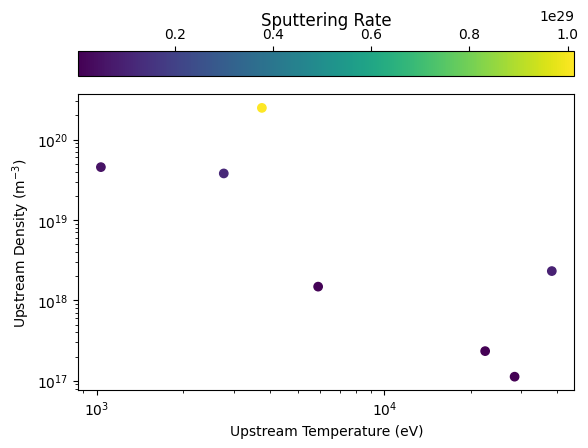

In [198]:

fig, axs = plt.subplots(1, 1)

axs = [axs]
axs[0].set_title("Sputtering Rate", pad=50)
tu_im = axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], c = df_simple_model_train["sputtering rate"])

axs[0].set_xlabel("Upstream Temperature (eV)")
axs[0].set_ylabel("Upstream Density (m$^{-3}$)")

axs[0].set_xscale('log')
axs[0].set_yscale('log')
plt.colorbar(tu_im, ax=axs[0], orientation="horizontal", location="top")

plt.show()

In [ ]:
# Define the name of the dataset
simple_model_dataset_id = "Simple_Model_Data"

# Initialise a Dataset object
simple_model_dataset = tl.Dataset(id=simple_model_dataset_id)

# Upload the dataset to the cloud
simple_model_dataset.upload(df_simple_model_train)

In [205]:
# Initialise emulator
simple_model_emulator_id = "Simple_Model_GP"

simple_model_emulator = tl.Emulator(id=simple_model_emulator_id)

# Train the emulator
simple_model_emulator.train(dataset=simple_model_dataset,
                    inputs=["upstream temperature", "upstream density"],
                    outputs=["sputtering rate"],
                      verbose=True)

Emulator 'Simple_Model_GP' has begun training.
0:00:00: Job status: processing
0:00:01: Job status: processing
0:00:03: Job status: processing
0:00:05: Job status: processing
0:00:07: Job status: success
Training of emulator Simple_Model_GP is complete!


We have now trained a surrogate model for our simple 2 point model.

This surrogate model can be called with an upstream temperature and an upstream density and predict the sputtering yield.

In [206]:
# Make many input data points
nmesh = 20
ts = log_space(*upstream_temperature_range, nmesh)
ns = log_space(*upstream_density_range, nmesh+1)
tt, nn = np.meshgrid(ts, ns, indexing='ij')


df_simple_model_full = pd.DataFrame(
    {"upstream temperature": tt.flatten(),
     "upstream density":     nn.flatten(),
     }
)

In [ ]:
# Predictions on full data
simple_model_predictions = simple_model_emulator.predict(df_simple_model_full[["upstream temperature", "upstream density"]])
simple_model_predictions_df = pd.concat([simple_model_predictions[0], simple_model_predictions[1]], axis=1)
simple_model_mean, simple_model_stdev = simple_model_predictions_df.iloc[:, 0].values, simple_model_predictions_df.iloc[:, 1].values

Job predict process ID: predict-florentine-longing-sidecar
0:00:00: Job status: processing
0:00:01: Job status: processing
0:00:03: Job status: processing
0:00:05: Job status: processing
0:00:07: Job status: success
Mean predictions:
     sputtering rate
0       1.684904e+27
1       1.688743e+27
2       1.695643e+27
3       1.708149e+27
4       1.731131e+27
..               ...
415     5.390562e+28
416     5.390562e+28
417     5.390562e+28
418     5.390562e+28
419     5.390562e+28

[420 rows x 1 columns]
Standard deviation predictions:
     sputtering rate
0       5.552482e+27
1       5.547170e+27
2       5.537754e+27
3       5.521108e+27
4       5.491817e+27
..               ...
415     3.699727e+28
416     3.699727e+28
417     3.699727e+28
418     3.699727e+28
419     3.699727e+28

[420 rows x 1 columns]


We have now made many predictions covering the full parameter space using our surrogate model!

Let's plot these predictions alongside the uncertainty

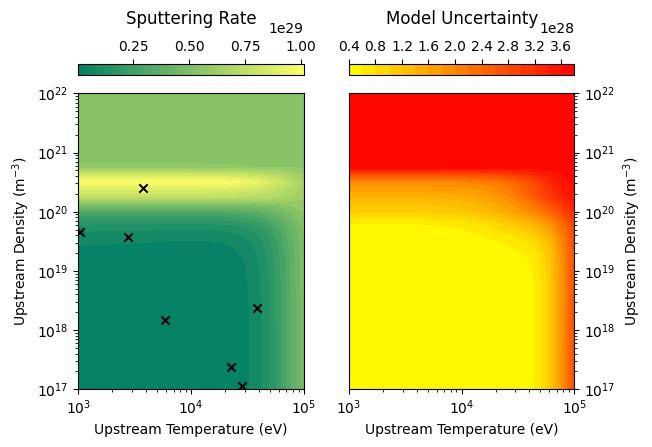

In [208]:
ss = simple_model_mean.reshape((len(ts), len(ns)))
ee = simple_model_stdev.reshape((len(ts), len(ns)))

fig, axs = plt.subplots(1, 2)
axs[0].set_title("Sputtering Rate", pad=50)
axs[1].set_title("Model Uncertainty", pad=50)

tu_cf = axs[0].contourf(
            tt,
            nn,
            ss,
            cmap=cmap,
            levels=levels,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )
tu_im = axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], c = df_simple_model_train["sputtering rate"], cmap=cmap)
axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], marker='x', c='k')
tu_cf = axs[1].contourf(
            tt,
            nn,
            ee,
            cmap=uncert_cmap,
            levels=levels,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )

for ax in axs:
    ax.set_xlabel("Upstream Temperature (eV)")
    ax.set_ylabel("Upstream Density (m$^{-3}$)")
    ax.set_xscale('log')
    ax.set_yscale('log')
axs[1].yaxis.tick_right()  # Move ticks to the right
axs[1].yaxis.set_label_position("right")  # Move label to the right
axs[1].spines['right'].set_position(('outward', 0))  # Make the right spine visible
plt.colorbar(tu_im, ax=axs[0], orientation="horizontal", location="top")
plt.colorbar(tu_cf, ax=axs[1], orientation="horizontal", location="top")

plt.show()

Our uncertainty is huge!

We need to sample from our full model more if we are to improve the validity of our surrogate model.

Now we want to suggest some new regions of parameter space to sample. We hope that these suggestions will improve the uncertainty of our surrogate model

In [210]:

df_suggested_next_sample, _ = simple_model_emulator.recommend(num_points=1,
                                        acq_func="explore"
                                        # acq_func="ExpectedImprovement"
                                        )

Job recommend process ID: recommend-tender-brindle-mum
0:00:00: Job status: processing
0:00:01: Job status: processing
0:00:03: Job status: processing
0:00:05: Job status: processing
0:00:07: Job status: success
Recommended points:
   upstream temperature  upstream density
0          38240.701584      1.718554e+20


Let's evaluate our model at this point

In [211]:

new_t_u, new_n_u = df_suggested_next_sample["upstream temperature"], df_suggested_next_sample["upstream density"] 
new_sputtering = NonLinearTwoPointModel(upstream_temperature=new_t_u, upstream_density=new_n_u)()

df_new_train = pd.DataFrame(
    {"upstream temperature": new_t_u,
     "upstream density":     new_n_u,
     "sputtering rate":      new_sputtering
     }
)
df_simple_model_improved_train = pd.concat([df_simple_model_train, df_new_train], ignore_index=True)

# Initialise a Dataset object
simple_model_improved_dataset = tl.Dataset(id="Simple Model Improved Dataset")

# Upload the dataset to the cloud
simple_model_improved_dataset.upload(df_simple_model_improved_train)

# Initialise emulator
simple_model_improved_emulator = tl.Emulator(id="Simple Model Improved")

# Train the emulator
simple_model_improved_emulator.train(dataset=simple_model_improved_dataset,
                    inputs=["upstream temperature", "upstream density"],
                    outputs=["sputtering rate"],
                      verbose=True)


Emulator 'Simple Model Improved' has begun training.
0:00:00: Job status: processing
0:00:01: Job status: processing
0:00:03: Job status: processing
0:00:05: Job status: processing
0:00:08: Job status: processing
0:00:10: Job status: success
Training of emulator Simple Model Improved is complete!


Let's make our predictions with this improved model

In [212]:

# Predictions on full data
simple_model_improved_predictions = simple_model_improved_emulator.predict(df_simple_model_full[["upstream temperature", "upstream density"]])
simple_model_improved_predictions_df = pd.concat([simple_model_improved_predictions[0], simple_model_improved_predictions[1]], axis=1)
simple_model_improved_mean, simple_model_improved_stdev = simple_model_improved_predictions_df.iloc[:, 0].values, simple_model_improved_predictions_df.iloc[:, 1].values

Job predict process ID: predict-tall-admitted-durian
0:00:00: Job status: processing
0:00:01: Job status: processing
0:00:03: Job status: processing
0:00:05: Job status: processing
0:00:07: Job status: success
Mean predictions:
     sputtering rate
0       5.649061e+26
1       5.722724e+26
2       5.859053e+26
3       6.118070e+26
4       6.629518e+26
..               ...
415     3.032704e+29
416     3.032704e+29
417     3.032704e+29
418     3.032704e+29
419     3.032704e+29

[420 rows x 1 columns]
Standard deviation predictions:
     sputtering rate
0       2.728745e+28
1       2.723776e+28
2       2.715604e+28
3       2.703145e+28
4       2.687387e+28
..               ...
415     3.867114e+29
416     3.867114e+29
417     3.867114e+29
418     3.867114e+29
419     3.867114e+29

[420 rows x 1 columns]


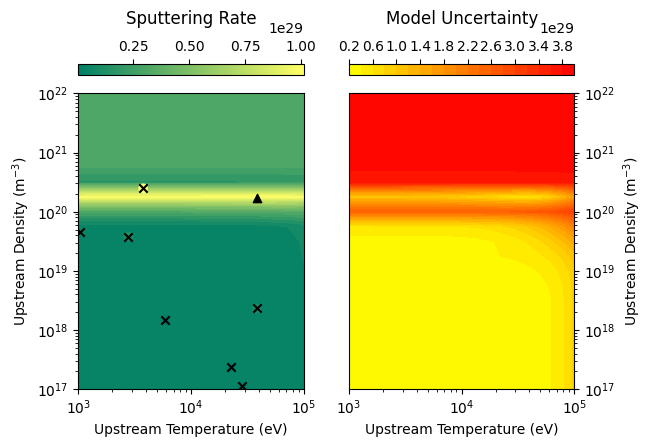

In [213]:

ss = simple_model_improved_mean.reshape((len(ts), len(ns)))
ee = simple_model_improved_stdev.reshape((len(ts), len(ns)))


fig, axs = plt.subplots(1, 2)
axs[0].set_title("Sputtering Rate", pad=50)
axs[1].set_title("Model Uncertainty", pad=50)
# tu_im = axs[0].scatter(np.exp(df_train["upstream temperature"]), np.exp(df_train["upstream density"]), c = np.exp(df_train["sputtering rate"]))
tu_cf = axs[0].contourf(
            tt,
            nn,
            ss,
            cmap=cmap,
            levels=levels,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )
tu_im = axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], c = df_simple_model_train["sputtering rate"], cmap=cmap)
axs[0].scatter(df_simple_model_train["upstream temperature"], df_simple_model_train["upstream density"], marker='x', c='k')
axs[0].scatter(new_t_u, new_n_u, marker='^', c='k')
tu_cf = axs[1].contourf(
            tt,
            nn,
            ee,
            cmap=uncert_cmap,
            levels=20,
            # alpha=alpha_fn,
            # vmin=vmin,
            # vmax=vmax,
        )

for ax in axs:
    ax.set_xlabel("Upstream Temperature (eV)")
    ax.set_ylabel("Upstream Density (m$^{-3}$)")
    ax.set_xscale('log')
    ax.set_yscale('log')
axs[1].yaxis.tick_right()  # Move ticks to the right
axs[1].yaxis.set_label_position("right")  # Move label to the right
axs[1].spines['right'].set_position(('outward', 0))  # Make the right spine visible
plt.colorbar(tu_im, ax=axs[0], orientation="horizontal", location="top")
plt.colorbar(tu_cf, ax=axs[1], orientation="horizontal", location="top")

plt.show()

Let's make another suggestion for improving our model

In [214]:

df_max_new_improved, _ = simple_model_improved_emulator.recommend(num_points=1,
                                        acq_func="explore"
                                        # acq_func="ExpectedImprovement"
                                        )

Job recommend process ID: recommend-ink-quill-riverbed
0:00:00: Job status: processing
0:00:01: Job status: processing
0:00:03: Job status: processing
0:00:05: Job status: processing
0:00:08: Job status: success
Recommended points:
   upstream temperature  upstream density
0          38240.701584      1.155105e+20


In [ ]:

new_t_u, new_n_u = [5000, 2000.], [8.e19, 1.e19]
new_sputtering = NonLinearTwoPointModel(upstream_temperature=new_t_u, upstream_density=new_n_u)()

print(new_sputtering)

[11604.51812155 11604.51812155]
[11604.51812155 11604.51812155]
[11604.51812155 11604.51812155]
[11604.51829447 11604.51812155]
[11604.51812155 11604.51829447]
[191911.70298533 153150.61823331]
[468341.63516401 356903.3006044 ]
[760378.91373346 561286.86086913]
[873288.22234264 630996.22733791]
[891452.05996499 634249.2418539 ]
[892193.8319776  627529.92863242]
[892215.04255096 620401.20453643]
[892296.20319506 585376.15142732]
[892299.22895467 584690.19427549]
[892299.07339889 584765.5682625 ]
[892299.05125569 584774.82144017]
[892299.05163126 584774.66449308]
[892299.05163126 584774.66449192]
[76.89238297 50.39198167]
[7.10152777e+25 3.55076388e+24]


Finally, we will tidy up our folder

In [182]:
# Delete emulator and dataset
new_emulator.delete()
dataset.delete()
improved_emulator.delete()
improved_dataset.delete()

We can see there's a rough positive correlation between the two; as magnetic field increases, so does energy confinement time. However, they are not perfectly correlated and the relationship seems very unclear and messy. This is because there are more than 7 other important parameters changing across these experiments, so of course it's difficult to see a clear relationship when only 1 of the features is used for plotting.